# Classification of Pet's Real-Life Images

Lab Assignment from [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners).

Now it's time to deal with more challenging task - classification of the original [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Let's start by loading and visualizing the dataset.

In [ ]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!tar xfz images.tar.gz
!rm images.tar.gz

We will define generic function to display a series of images from a list:

In [2]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

You can see that all images are located in one directory called `images`, and their name contains the name of the class (breed):

In [ ]:
fnames = os.listdir('images')[:5]
display_images([Image.open(os.path.join('images',x)) for x in fnames],titles=fnames,fontsize=30)

To simplify classification and use the same approach to loading images as in the previous part, let's sort all images into corresponding directories:

In [3]:
for fn in os.listdir('images'):
    cls = fn[:fn.rfind('_')].lower()
    os.makedirs(os.path.join('images',cls),exist_ok=True)
    os.replace(os.path.join('images',fn),os.path.join('images',cls,fn))

Let's also define the number of classes in our dataset:

In [4]:
num_classes = len(os.listdir('images'))
num_classes

37

## Preparing dataset for Deep Learning

To start training our neural network, we need to convert all images to tensors, and also create tensors corresponding to labels (class numbers). Most neural network frameworks contain simple tools for dealing with images:
* In Tensorflow, use `tf.keras.preprocessing.image_dataset_from_directory`
* In PyTorch, use `torchvision.datasets.ImageFolder`

As you have seen from the pictures above, all of them are close to square image ratio, so we need to resize all images to square size. Also, we can organize images in minibatches.

In [5]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder('images', transform=transform)
print(f"Total images: {len(dataset)}")
print(f"Classes: {dataset.classes}")

/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <367D4265-B20F-34BD-94EB-4F3EE47C385B> /Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/image.so
  Reason: tried: '/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/li016390/miniforge3/envs/ai4beg/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Othe

Total images: 7390
Classes: ['abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'bengal', 'birman', 'bombay', 'boxer', 'british_shorthair', 'chihuahua', 'egyptian_mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'maine_coon', 'miniature_pinscher', 'newfoundland', 'persian', 'pomeranian', 'pug', 'ragdoll', 'russian_blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'siamese', 'sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


Now we need to separate dataset into train and test portions:

In [6]:
from torch.utils.data import random_split

train_ratio = 0.8
train_size = int(train_ratio * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Train set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Train set size: 5912
Test set size: 1478


Now define data loaders:

In [7]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

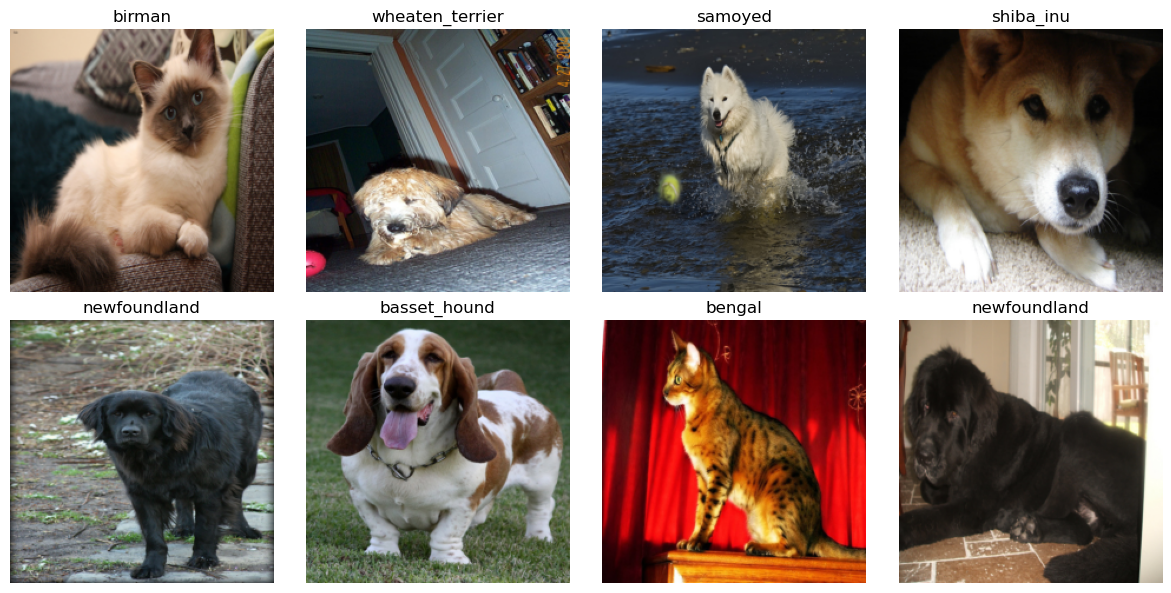

In [8]:
import matplotlib.pyplot as plt

def show_batch(loader, classes):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 6))
    for i in range(min(8, len(images))):
        img = images[i].permute(1, 2, 0).numpy()
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(classes[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(train_loader, dataset.classes)

## Define a neural network

For image classification, you should probably define a convolutional neural network with several layers. What to keep an eye for:
* Keep in mind the pyramid architecture, i.e. number of filters should increase as you go deeper
* Do not forget activation functions between layers (ReLU) and Max Pooling
* Final classifier can be with or without hidden layers, but the number of output neurons should be equal to number of classes.

An important thing is to get the activation function on the last layer + loss function right:
* In Tensorflow, you can use `softmax` as the activation, and `sparse_categorical_crossentropy` as loss. The difference between sparse categorical cross-entropy and non-sparse one is that the former expects output as the number of class, and not as one-hot vector.
* In PyTorch, you can have the final layer without activation function, and use `CrossEntropyLoss` loss function. This function applies softmax automatically. 

> **Hint:** In PyTorch, you can use `LazyLinear` layer instead of `Linear`, in order to avoid computing the number of inputs. It only requires one `n_out` parameter, which is number of neurons in the layer, and the dimension of input data is picked up automatically upon first `forward` pass.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 3 input channels (RGB), 16 filters
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 32 filters
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.LazyLinear(64)  
        self.fc2 = nn.Linear(64, num_classes)  

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # No activation here; CrossEntropyLoss will apply softmax
        return x

# Instantiate the model
model = SimpleCNN(num_classes)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): LazyLinear(in_features=0, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=37, bias=True)
)


## Train the Neural Network

Now we are ready to train the neural network. During training, please collect accuracy on train and test data on each epoch, and then plot the accuracy to see if there is overfitting.

In [10]:
import torch
import torch.optim as optim

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_acc_history = []
test_acc_history = []

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = correct / total
    train_acc_history.append(train_acc)

    # Evaluate on test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = correct / total
    test_acc_history.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch [1/10], Train Acc: 0.0328, Test Acc: 0.0494
Epoch [2/10], Train Acc: 0.0502, Test Acc: 0.0507
Epoch [3/10], Train Acc: 0.0507, Test Acc: 0.0487
Epoch [4/10], Train Acc: 0.0587, Test Acc: 0.0521
Epoch [5/10], Train Acc: 0.0705, Test Acc: 0.0575
Epoch [6/10], Train Acc: 0.0856, Test Acc: 0.0737
Epoch [7/10], Train Acc: 0.1235, Test Acc: 0.0995
Epoch [8/10], Train Acc: 0.1779, Test Acc: 0.0907
Epoch [9/10], Train Acc: 0.2461, Test Acc: 0.1008
Epoch [10/10], Train Acc: 0.3395, Test Acc: 0.1008


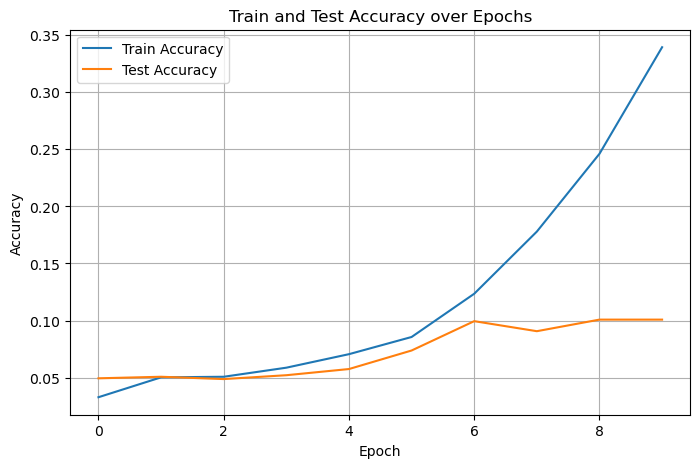

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(test_acc_history, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

Even if you have done everything correctly, you will probably see that the accuracy is quite low.

## Transfer Learning

To improve the accuracy, let's use pre-trained neural network as feature extractor. Feel free to experiment with VGG-16/VGG-19 models, ResNet50, etc.

> Since this training is slower, you may start with training the model for the small number of epochs, eg. 3. You can always resume training to further improve accuracy if needed.

We need to normalize our data differently for transfer learning, thus we will reload the dataset again using different set of transforms:

In [12]:
from torchvision import datasets, transforms, models

resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

resnet_dataset = datasets.ImageFolder('images', transform=resnet_transform)

# Split into train/test
train_size = int(0.8 * len(resnet_dataset))
test_size = len(resnet_dataset) - train_size
resnet_train_dataset, resnet_test_dataset = torch.utils.data.random_split(resnet_dataset, [train_size, test_size])

resnet_train_loader = torch.utils.data.DataLoader(resnet_train_dataset, batch_size=32, shuffle=True)
resnet_test_loader = torch.utils.data.DataLoader(resnet_test_dataset, batch_size=32, shuffle=False)

Let's load the pre-trained network:

In [13]:
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/li016390/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:03<00:00, 34.0MB/s]


Now define the classification model for your problem:
* In PyTorch, there is a slot called `classifier`, which you can replace with your own classifier for the desired number of classes.
* In TensorFlow, use VGG network as feature extractor, and build a `Sequential` model with VGG as first layer, and your own classifier on top

In [14]:
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, num_classes) #no classifier slot for restnet

Make sure to set all parameters of VGG feature extractor not to be trainable

In [15]:
for param in resnet.parameters():
    param.requires_grad = False
for param in resnet.fc.parameters():
    param.requires_grad = True

Now we can start the training. Be very patient, as training takes a long time, and our train function is not designed to print anything before the end of the epoch.

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)

num_epochs = 5  
train_acc_history = []
test_acc_history = []

for epoch in range(num_epochs):
    resnet.train()
    correct = 0
    total = 0
    for images, labels in resnet_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = correct / total
    train_acc_history.append(train_acc)

    
    resnet.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in resnet_test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = correct / total
    test_acc_history.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch [1/5], Train Acc: 0.7493, Test Acc: 0.9087
Epoch [2/5], Train Acc: 0.9308, Test Acc: 0.9235
Epoch [3/5], Train Acc: 0.9521, Test Acc: 0.9323
Epoch [4/5], Train Acc: 0.9623, Test Acc: 0.9296
Epoch [5/5], Train Acc: 0.9734, Test Acc: 0.9323


It seems much better now!

## Optional: Calculate Top 3 Accuracy

We can also computer Top 3 accuracy using the same code as in the previous exercise.


In [17]:
import torch

def top_k_accuracy(model, data_loader, device, k=3):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # Get top k predictions for each sample
            _, topk = outputs.topk(k, dim=1)
            # Check if true label is in top k predictions
            correct += sum([labels[i] in topk[i] for i in range(labels.size(0))])
            total += labels.size(0)
    return correct / total

top3_acc = top_k_accuracy(resnet, resnet_test_loader, device, k=3)
print(f"Top-3 Test Accuracy: {top3_acc:.4f}")

Top-3 Test Accuracy: 0.9905


## Bonus: Adverserial Boxer

Let's "optimize" a boxer picture to fool our model and make it classified as a cat.

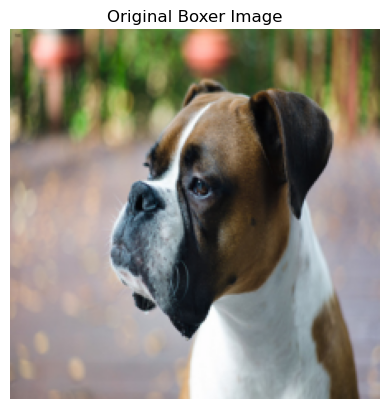

Will be classified as a persian


In [23]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import numpy as np

img_path = 'images/boxer/boxer_1.jpg'  
original_img = Image.open(img_path).convert('RGB')
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = preprocess(original_img).unsqueeze(0)

# Plot original image (unnormalized for display)
def imshow(tensor, title=None):
    img = tensor.clone().detach().cpu().squeeze(0)
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img = img.clamp(0, 1)
    npimg = img.permute(1, 2, 0).numpy()
    plt.imshow(npimg)
    if title: plt.title(title)
    plt.axis('off')
    plt.show()

imshow(img_tensor, title="Original Boxer Image")

cat_class_idx = None
for idx, name in enumerate(resnet_dataset.classes):
    if 'persian' in name:
        cat_class_idx = idx
        break
if cat_class_idx is None:
    raise ValueError("No class containing 'cat' found in dataset classes.")

print(f'Will be classified as a {resnet_dataset.classes[cat_class_idx]}')

Running through the network and optimizing the image

Epoch 0, loss: 9.9259, cat prob: 0.0000
Epoch 9, loss: 0.0254, cat prob: 0.9749


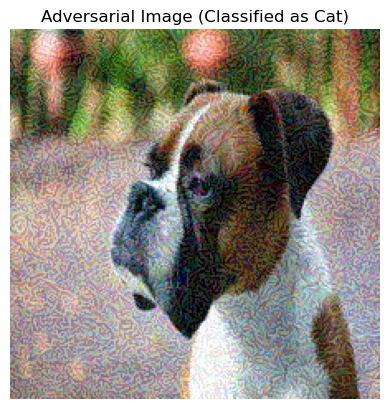

In [31]:
img_adv = img_tensor.clone().detach().to(device)
img_adv.requires_grad = True

optimizer = torch.optim.Adam([img_adv], lr=0.1)
epochs = 10

for epoch in range(epochs):
    optimizer.zero_grad()
    output = resnet(img_adv)
    loss = F.cross_entropy(output, torch.tensor([cat_class_idx], device=device))
    loss.backward()  
    optimizer.step()
    # Clamp the image to valid range after normalization
    img_adv.data = img_adv.data.clamp(-5, 5)

    if epoch % 20 == 0 or epoch == epochs - 1:
        probs = torch.softmax(output, dim=1)
        cat_prob = probs[0, cat_class_idx].item()
        print(f"Epoch {epoch}, loss: {loss.item():.4f}, cat prob: {cat_prob:.4f}")

# Plot adversarial image
imshow(img_adv, title="Adversarial Image (Classified as Cat)")

In [32]:
resnet.eval()
with torch.no_grad():
    output = resnet(img_adv)
    _, predicted_idx = torch.max(output, 1)
    predicted_class = resnet_dataset.classes[predicted_idx.item()]
    print(f"Predicted class for adversarial image: {predicted_class}")

Predicted class for adversarial image: persian
